# [Jev](https://typesafe.ai/blog/introducing-system-one-models-and-jev)

Jev takes **text + questions** and returns typed answers.


In [1]:
import os
import re
import shutil
from decimal import Decimal
from time import perf_counter

import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd
import pytesseract
from pathlib import Path
from dotenv import load_dotenv
from IPython.display import display
from matplotlib.patches import Rectangle
from PIL import Image, ImageOps
from typesafe_sdk import Choice, Noul, Score, TypeSafeClient

ASSETS = Path("./assets")

load_dotenv()
if not os.getenv("TYPESAFE_API_KEY"):
    raise RuntimeError("Set TYPESAFE_API_KEY, then rerun setup.")

MODEL = "jev-1.13.0"
plt.rcParams.update({"figure.figsize": (9, 3.5), "font.size": 12})
pd.set_option("display.max_colwidth", 100)

TESSERACT_CMD = os.getenv("TESSERACT_CMD") or shutil.which("tesseract")
if TESSERACT_CMD:
    pytesseract.pytesseract.tesseract_cmd = TESSERACT_CMD
print(f"JEV model: {MODEL}")
print("OCR:", TESSERACT_CMD or "Install Tesseract before running example 3.")

JEV model: jev-1.13.0
OCR: /opt/homebrew/bin/tesseract


In [2]:
PRICING_SOURCE = "https://docs.typesafe.ai/models"
PRICING_CHECKED_ON = "2026-09-19"
PRICING_USD_PER_MILLION = {
    "jev-1.13.0": {
        "input": Decimal("0.042"),
        "output": Decimal(0),
    },
}

## Quickstart


In [3]:
with TypeSafeClient(model=MODEL) as quickstart_client:
    quickstart_response = quickstart_client.system_one(
        state="I was charged twice. Please refund the duplicate payment.",
        questions={
            "refund": Noul(instructions="Is the customer requesting a refund?"),
        },
    )

print("P(refund requested):", quickstart_response.answers["refund"].noul)

P(refund requested): 0.99


In [4]:
def show_call_usage(response):
    rates = PRICING_USD_PER_MILLION.get(response.model)
    rows = []
    for direction in ("input", "output"):
        tokens = getattr(response.usage, f"{direction}_tokens")
        rate = rates[direction] if rates is not None else None
        cost = (
            Decimal(tokens) * rate / Decimal(1000000)
            if tokens is not None and rate is not None
            else None
        )
        rows.append(
            {
                "Token type": direction.title(),
                "API token count": tokens if tokens is not None else "Not reported",
                "USD / 1M tokens": f"${rate:.3f}"
                if rate is not None
                else "Unknown rate",
                "Estimated cost (USD)": f"${cost:.9f}"
                if cost is not None
                else "Unavailable",
            }
        )
    display(pd.DataFrame(rows).set_index("Token type"))


def ask_jev(state, questions):
    with TypeSafeClient(model=MODEL, timeout=45.0) as client:
        started = perf_counter()
        response = client.system_one(state=state, questions=questions)
        elapsed = perf_counter() - started
    print(f"{response.model} | {len(questions)} questions | {elapsed:.2f}s wall time")
    show_call_usage(response)
    return response

In [5]:
show_call_usage(quickstart_response)  # Reports the existing call; no new API request.

,API token count,USD / 1M tokens,Estimated cost (USD)
Token type,,,
Input,284,$0.042,$0.000011928
Output,20,$0.000,$0.000000000


## Choice vs Score vs Noul

| Primitive  | The question it answers                           | Returned value                                          | Here                             |
| ---------- | ------------------------------------------------- | ------------------------------------------------------- | -------------------------------- |
| **Choice** | Which of these alternatives fits?                 | One label + probabilities + confidence                  | Which team owns the problem?     |
| **Score**  | Where does this sit on described, ordered levels? | Probability-weighted level + probabilities + confidence | How frustrated is the writer?    |
| **Noul**   | Is this statement true?                           | `P(yes)` between 0 and 1                                | Does this need urgent attention? |

A three-level **Score** ranges from **0 to 2**, because the levels are zero-indexed. A **Noul** of 0.5 means yes and no are similarly likely. Choice and Score confidence summarize how concentrated the answer distribution is.


In [6]:
ticket = {
    "product": "An online store with a Stripe integration",
    "message": """
Hi team, checkout returns HTTP 500 for every customer after today's
deployment. Nobody can pay, and our launch starts in 20 minutes.
Could you take a look right away? Thanks for your help.
""".strip(),
}
triage_questions = {
    "team": Choice(
        instructions="Which team should own the main issue in `message`?",
        criteria={
            "billing": "Incorrect charges, refunds, invoices, or subscription billing",
            "engineering": "Broken application behavior, errors, or failed integrations",
            "sales": "Product selection, pricing quotes, or purchase enquiries",
            "other": "No listed team fits, or there is too little information to route",
        },
    ),
    "frustration": Score(
        instructions="How frustrated is the writer's tone in `message`? Judge tone, not business impact.",
        criteria=[
            "Calm or polite; describes the issue without expressing frustration",
            "Expresses frustration or disappointment while remaining civil",
            "Expresses strong anger or hostility toward the service or team",
        ],
    ),
    "urgent": Noul(
        instructions="""
Does `message` describe a current business-blocking problem or an
explicit near-term deadline that requires immediate attention?
""".strip(),
    ),
}
triage_response = ask_jev(ticket, triage_questions)
team = triage_response.answers["team"]
frustration = triage_response.answers["frustration"]
urgent = triage_response.answers["urgent"]

jev-1.13.0 | 3 questions | 0.69s wall time


,API token count,USD / 1M tokens,Estimated cost (USD)
Token type,,,
Input,551,$0.042,$0.000023142
Output,77,$0.000,$0.000000000


,primitive,value,meaning,confidence
0,Choice,engineering,Selected team,1.0
1,Score,0.09,Frustration position on 0–2,0.86
2,Noul,0.99,Probability that urgent is true,—


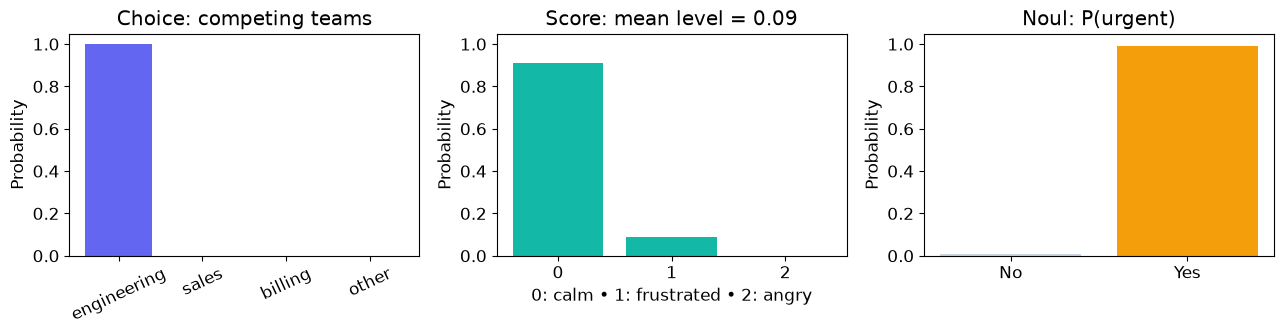

Score reconstructed from probabilities: 0.090


In [7]:
display(
    pd.DataFrame(
        [
            {
                "primitive": "Choice",
                "value": team.choice,
                "meaning": "Selected team",
                "confidence": team.confidence,
            },
            {
                "primitive": "Score",
                "value": round(frustration.score, 3),
                "meaning": "Frustration position on 0–2",
                "confidence": frustration.confidence,
            },
            {
                "primitive": "Noul",
                "value": round(urgent.noul, 3),
                "meaning": "Probability that urgent is true",
                "confidence": None,
            },
        ]
    ).fillna("—")
)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
axes[0].bar(team.probabilities.keys(), team.probabilities.values(), color="#6366f1")
axes[0].set_title("Choice: competing teams")
axes[0].tick_params(axis="x", rotation=25)
axes[1].bar(
    [str(k) for k in frustration.probabilities],
    frustration.probabilities.values(),
    color="#14b8a6",
)
axes[1].set_title(f"Score: mean level = {frustration.score:.2f}")
axes[1].set_xlabel("0: calm • 1: frustrated • 2: angry")
axes[2].bar(["No", "Yes"], [1 - urgent.noul, urgent.noul], color=["#cbd5e1", "#f59e0b"])
axes[2].set_title("Noul: P(urgent)")
for ax in axes:
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Probability")
fig.tight_layout()
plt.show()

# Score is an expected level, not the probability of one selected level.
weighted_level = sum(int(k) * p for k, p in frustration.probabilities.items())
print(f"Score reconstructed from probabilities: {weighted_level:.3f}")

In [8]:
def routing_preview(team_answer, urgent_answer, confidence_floor=0.75):
    if team_answer.choice == "other" or team_answer.confidence < confidence_floor:
        return "Review queue: team is unclear"
    if 0.20 < urgent_answer.noul < 0.80:
        return f"{team_answer.choice} queue: review urgency"
    priority = "immediate" if urgent_answer.noul >= 0.80 else "normal"
    return f"{team_answer.choice} queue, {priority} priority"


print("Routing preview:", routing_preview(team, urgent))

Routing preview: engineering queue, immediate priority


## Semantic ranking

Imagine a RAG system has retrieved four candidates. We will score each for **relevance to the query** and **implementation detail**, then combine those two features in Python.


In [9]:
search_query = """
How can RAG retrieval handle both exact product IDs and paraphrased questions?
""".strip()

documents = {
    "hybrid_design": {
        "title": "Hybrid retrieval architecture",
        "text": """
Use a lexical index to preserve rare product identifiers and a dense
index to match paraphrases. Fuse both ranked lists using reciprocal
rank fusion, then rerank the combined candidates. This design note
explains the tradeoffs but contains no code or execution steps.
""".strip(),
    },
    "dense_notebook": {
        "title": "Runnable dense retrieval notebook",
        "text": """
Install sentence-transformers and faiss-cpu. Encode your documents
with SentenceTransformer, normalize vectors, add them to IndexFlatIP,
then encode a query and call index.search(query_vector, k=10).
Includes an executable notebook and sample documents for paraphrase
retrieval. Exact product IDs are not handled with a lexical index.
""".strip(),
    },
    "bm25_recipe": {
        "title": "BM25 product lookup recipe",
        "text": """
Tokenize a product catalogue while retaining hyphens in SKU codes.
Build a BM25 index and test queries containing full product IDs.
The guide includes pseudocode and a checklist, but no runnable code.
It covers exact term matching only, without semantic retrieval.
""".strip(),
    },
    "training_loop": {
        "title": "PyTorch image classifier tutorial",
        "text": """
A complete runnable CIFAR-10 notebook: install PyTorch, load images,
define a CNN, run optimizer steps, and plot validation accuracy.
Includes the full training loop and downloadable example data.
""".strip(),
    },
}
ranking_rubrics = {
    "relevance": [
        "The document does not address the retrieval problem in the query",
        "The document mentions related retrieval ideas without addressing a requested need",
        "The document addresses one of exact identifier lookup or paraphrase retrieval",
        "The document explains how to combine exact identifier lookup with paraphrase retrieval",
    ],
    "implementation": [
        "Conceptual discussion only, with no implementation instructions",
        "Names components to use but provides no ordered implementation procedure",
        "Provides an ordered procedure or pseudocode, but no runnable example",
        "Provides or explicitly links a runnable example with setup and sample inputs",
    ],
}

In [10]:
ranking_questions = {}
for doc_id in documents:
    ranking_questions[f"{doc_id}_relevance"] = Score(
        instructions=f"How well does `documents.{doc_id}.text` address `query`?",
        criteria=ranking_rubrics["relevance"],
    )
    ranking_questions[f"{doc_id}_implementation"] = Score(
        instructions=f"""
How much concrete implementation guidance does `documents.{doc_id}.text`
provide or explicitly describe? Judge implementation detail, regardless of relevance.
""".strip(),
        criteria=ranking_rubrics["implementation"],
    )

In [11]:
print(ranking_questions["hybrid_design_relevance"].instructions)
print(ranking_questions["hybrid_design_relevance"].criteria)

How well does `documents.hybrid_design.text` address `query`?
['The document does not address the retrieval problem in the query', 'The document mentions related retrieval ideas without addressing a requested need', 'The document addresses one of exact identifier lookup or paraphrase retrieval', 'The document explains how to combine exact identifier lookup with paraphrase retrieval']


In [12]:
print(ranking_questions["hybrid_design_implementation"].instructions)
print(ranking_questions["hybrid_design_implementation"].criteria)

How much concrete implementation guidance does `documents.hybrid_design.text`
provide or explicitly describe? Judge implementation detail, regardless of relevance.
['Conceptual discussion only, with no implementation instructions', 'Names components to use but provides no ordered implementation procedure', 'Provides an ordered procedure or pseudocode, but no runnable example', 'Provides or explicitly links a runnable example with setup and sample inputs']


In [13]:
ranking_response = ask_jev(
    {"query": search_query, "documents": documents}, ranking_questions
)
ranking_features = pd.DataFrame(
    [
        {
            "id": doc_id,
            "title": doc["title"],
            **{
                dimension: ranking_response.answers[f"{doc_id}_{dimension}"].score
                / (len(levels) - 1)
                for dimension, levels in ranking_rubrics.items()
            },
            "relevance_confidence": ranking_response.answers[
                f"{doc_id}_relevance"
            ].confidence,
            "implementation_confidence": ranking_response.answers[
                f"{doc_id}_implementation"
            ].confidence,
        }
        for doc_id, doc in documents.items()
    ]
).set_index("id")
display(ranking_features.round(3))

jev-1.13.0 | 8 questions | 0.65s wall time


,API token count,USD / 1M tokens,Estimated cost (USD)
Token type,,,
Input,1444,$0.042,$0.000060648
Output,156,$0.000,$0.000000000


,title,relevance,implementation,relevance_confidence,implementation_confidence
id,,,,,
hybrid_design,Hybrid retrieval architecture,1.000,0.337,1.0,0.61
dense_notebook,Runnable dense retrieval notebook,0.667,0.993,1.0,0.98
bm25_recipe,BM25 product lookup recipe,0.667,0.657,1.0,0.97
training_loop,PyTorch image classifier tutorial,0.000,0.997,1.0,0.99


In [14]:
def rank_documents(features, relevance_weight):
    if not 0 <= relevance_weight <= 1:
        raise ValueError("relevance_weight must be between 0 and 1")
    return features.assign(
        combined=(
            relevance_weight * features["relevance"]
            + (1 - relevance_weight) * features["implementation"]
        )
    ).sort_values("combined", ascending=False, kind="stable")


def show_ranking(relevance_weight=0.8):
    ranked = rank_documents(ranking_features, relevance_weight)
    plot = ranked.iloc[::-1]
    fig, ax = plt.subplots(figsize=(10, 3.5))
    left = relevance_weight * plot["relevance"]
    ax.barh(plot["title"], left, label="Relevance contribution", color="#6366f1")
    ax.barh(
        plot["title"],
        (1 - relevance_weight) * plot["implementation"],
        left=left,
        label="Implementation contribution",
        color="#14b8a6",
    )
    ax.set(
        xlim=(0, 1.05),
        xlabel="Weighted score (0-1)",
        title="Reranking documents by weighted relevance vs. implementation",
    )
    ax.legend(loc="lower right")
    fig.tight_layout()
    plt.show()


slider = widgets.FloatSlider(
    value=0.8,
    min=0,
    max=1,
    step=0.05,
    description="Relevance",
    continuous_update=False,
)
ranking_output = widgets.interactive_output(show_ranking, {"relevance_weight": slider})
display(slider, ranking_output)

FloatSlider(value=0.8, continuous_update=False, description='Relevance', max=1.0, step=0.05)

Output()

## Receipt Extraction

Turn an image into text with OCR and pass the result to JEV. It will select the printed total, recognize alcoholic items, and preview a fictional receipt-review policy.


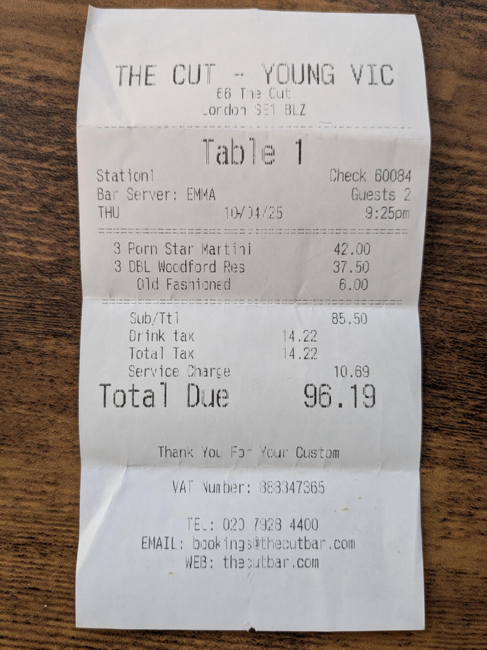

66 Tae Gu
ordo a S21 BLZ
| Table 1
Station) Check 60084
Bar Server: EMMA Guests 2
THU V0 4005 9:25pm
: 3 Porn Star Martiai 42.00
3 DBL Woadford Res 37,50)
Old Fasaioned 6.00
Sub/Tt I B5 50
Orink tax |4.22
Total Tax ld 22
Service Charce 10.69
= al ry cr cs ‘a
Total Due 96.19
Thank You Fa* Your Custom
VAT Numbers eisgd7365
rE.: 020 7988 4400
EMAIL: book ingsdtheeutbar.cam
: WEB: thazutbar.cem


In [15]:
IMAGE_PATH = ASSETS / "receipt.jpg"

receipt_image = ImageOps.exif_transpose(Image.open(IMAGE_PATH)).convert("RGB")
preview = receipt_image.copy()
preview.thumbnail((600, 650))
display(preview)

ocr_words = pytesseract.image_to_data(
    ImageOps.grayscale(receipt_image),
    lang="eng",
    config="--psm 6",  # One text block, preserving receipt lines.
    output_type=pytesseract.Output.DATAFRAME,
    pandas_config={"keep_default_na": False},
    timeout=45,
)
ocr_words["text"] = ocr_words["text"].fillna("").astype(str).str.strip()
ocr_words = ocr_words[(ocr_words["conf"] >= 0) & ocr_words["text"].ne("")].copy()

receipt_lines = [
    " ".join(group["text"])
    for _, group in ocr_words.groupby(
        ["page_num", "block_num", "par_num", "line_num"], sort=False
    )
]
receipt_text = "\n".join(receipt_lines)
print(receipt_text)

In [16]:
def find_amount_candidates(words):
    pattern = re.compile(r"(?<![\w.,])\d+(?:,\d{3})*\.\d{2}(?![\w.,])")
    candidates = {}
    groups = words.groupby(["page_num", "block_num", "par_num", "line_num"], sort=False)
    for line_number, (_, group) in enumerate(groups, start=1):
        line_text = " ".join(group["text"])
        for _, word in group.iterrows():
            for match in pattern.finditer(word["text"]):
                candidate_id = f"amount_{len(candidates)}"
                candidates[candidate_id] = {
                    "value": match.group(),
                    "line_number": line_number,
                    "source_line": line_text,
                    "ocr_confidence": float(word["conf"]),
                    "box": [int(word[k]) for k in ("left", "top", "width", "height")],
                }
    return candidates

In [17]:
amount_candidates = find_amount_candidates(ocr_words)
display(pd.DataFrame.from_dict(amount_candidates, orient="index").drop(columns="box"))

,value,line_number,source_line,ocr_confidence
amount_0,42.00,7,: 3 Porn Star Martiai 42.00,62.484821
amount_1,6.00,9,Old Fasaioned 6.00,93.567451
amount_2,4.22,11,Orink tax |4.22,13.136654
amount_3,10.69,13,Service Charce 10.69,90.453712
amount_4,96.19,15,Total Due 96.19,66.000671


In [18]:
receipt_state = {
    "ocr_text": receipt_text,
    "amount_candidates": {
        key: {"value": item["value"], "source_line": item["source_line"]}
        for key, item in amount_candidates.items()
    },
}
receipt_questions = {
    "total": Choice(
        instructions="""
Which candidate in `amount_candidates` is the final total due for the
receipt in `ocr_text`? Select the printed payable total, not a subtotal,
individual item, tax, or service charge. Do not calculate a new amount.
""".strip(),
        criteria={
            key: f"The amount {item['value']} on the line: {item['source_line']}"
            for key, item in amount_candidates.items()
        }
        | {"none": "No candidate clearly represents the final payable total"},
    ),
    "alcohol": Noul(
        instructions="""
Does `ocr_text` include an alcoholic drink among the purchased items?
Use item names, including recognizable cocktail or spirit names despite
minor OCR errors. A bar or restaurant name alone is insufficient.
""".strip(),
    ),
}
receipt_response = ask_jev(receipt_state, receipt_questions)
selected_total = receipt_response.answers["total"]
alcohol = receipt_response.answers["alcohol"]
selected_candidate = amount_candidates.get(selected_total.choice)
print("Selected candidate:", selected_total.choice)
print(f"Total-selection confidence: {selected_total.confidence:.3f}")
print(f"P(alcohol present): {alcohol.noul:.3f}")

jev-1.13.0 | 2 questions | 0.72s wall time


,API token count,USD / 1M tokens,Estimated cost (USD)
Token type,,,
Input,957,$0.042,$0.000040194
Output,90,$0.000,$0.000000000


Selected candidate: amount_4
Total-selection confidence: 1.000
P(alcohol present): 0.980


,decision,reason,total
0,REVIEW,Verify the total against the image,96.19


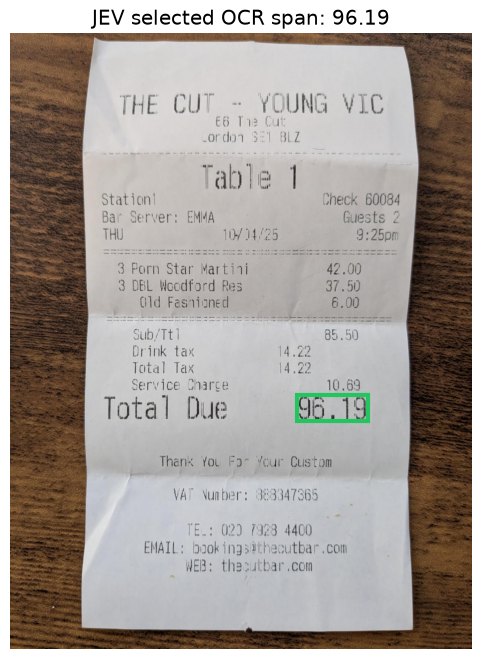

Evidence: Total Due 96.19
Exact value: 96.19


In [19]:
def receipt_review(total_answer, alcohol_answer, candidates, limit=Decimal("100.00")):
    item = candidates.get(total_answer.choice)
    amount = Decimal(item["value"].replace(",", ""))
    if total_answer.confidence < 0.80 or item["ocr_confidence"] < 70:
        reason = "Verify the total against the image"
    elif alcohol_answer.noul >= 0.80:
        reason = "Alcohol evidence: item-level review required"
    elif alcohol_answer.noul > 0.20:
        reason = "Uncertain alcohol evidence"
    elif amount > limit:
        reason = "Printed total exceeds the demo review limit"
    else:
        return {
            "decision": "READY FOR REVIEWER",
            "reason": "Demo checks passed",
            "total": amount,
        }
    return {"decision": "REVIEW", "reason": reason, "total": amount}


receipt_result = receipt_review(selected_total, alcohol, amount_candidates)
display(pd.DataFrame([receipt_result]))

if selected_candidate:
    fig, ax = plt.subplots(figsize=(6, 8))
    ax.imshow(receipt_image)
    x, y, width, height = selected_candidate["box"]
    ax.add_patch(
        Rectangle(
            (x - 5, y - 5),
            width + 10,
            height + 10,
            fill=False,
            edgecolor="#22c55e",
            linewidth=3,
        )
    )
    ax.set_title(f"JEV selected OCR span: {selected_candidate['value']}")
    ax.axis("off")
    plt.show()
    print("Evidence:", selected_candidate["source_line"])
    print("Exact value:", receipt_result["total"])

## References

- [Python SDK](https://docs.typesafe.ai/sdk/python)
- [Model versions](https://docs.typesafe.ai/models)
- [OCR wrapper](https://github.com/madmaze/pytesseract)
